[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EnsaeStatApp/CorrelationEquityBond/blob/main/RegimeDetector/HMMMarket_Backtest_EquityBond.ipynb)

# Corrélation indices actions-obligations : Prédiction des régimes de marchés entre le S&P et le T-Bond 10y de 70 à 2025

Ce code propose un backtest expanding de 2005 à 2025 en essayant de prédire les régimes de marchés (et d'en deduire une prédiction de la matrice de cov entre les actifs à la prochaine date). On commence par fitter un premier HMMMarket de 1970 à 2005 puis on refit un modèle à chaque date de refit. Pour déterminer si le nouveau modèle semble stable, on utilise le HMMCoherenceChecker avec différentes initialisations.

# Connexion au github

In [6]:
import os
import sys

# 1. Vérification de l'environnement
if 'google.colab' in str(get_ipython()):
    repo_url = 'https://github.com/EnsaeStatApp/CorrelationEquityBond.git'
    repo_name = 'CorrelationEquityBond'

    # 2. Clone du repo
    if not os.path.exists(repo_name):
        !git clone {repo_url}

    # 3. Déplacement dans le dossier du projet
    os.chdir(repo_name)

    # 4. Ajout du chemin au système pour l'import des modules .py
    sys.path.append(os.getcwd())

    print(f"Répertoire actuel : {os.getcwd()}")

Cloning into 'CorrelationEquityBond'...
remote: Enumerating objects: 762, done.
remote: Counting objects: 100% (231/231), done.
remote: Compressing objects: 100% (158/158), done.
remote: Total 762 (delta 171), reused 73 (delta 73), pack-reused 531 (from 1)
Receiving objects: 100% (762/762), 19.89 MiB | 12.01 MiB/s, done.
Resolving deltas: 100% (371/371), done.
Répertoire actuel : /content/CorrelationEquityBond/CorrelationEquityBond


# Installation de ssm

In [7]:
!pip install git+https://github.com/lindermanlab/ssm.git

  Cloning https://github.com/lindermanlab/ssm.git to /tmp/pip-req-build-eqn6mgsf
  Running command git clone --filter=blob:none --quiet https://github.com/lindermanlab/ssm.git /tmp/pip-req-build-eqn6mgsf
  Resolved https://github.com/lindermanlab/ssm.git to commit eb6c8aa33e5311d3564075807dec340759dd8081
  Preparing metadata (setup.py) ... done


# Préparation des données

In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv("monthly_data/dataset_stat_app_vf_with_gold.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date").sort_index()
df.drop(columns="Unnamed: 0", inplace=True)

ASSET_VARS = ["Stock_Log_Return", "Bond_Log_Return"]
asset_names = ["S&P", "T-bond 10y"]
annualise_factor = np.sqrt(12) # mensuel

cols = ASSET_VARS
df_model = df[cols].dropna().copy()
Y_raw = df_model[ASSET_VARS].values.astype(float)

dates = df_model.index
split_date = pd.Timestamp("2025-01-01") # on fait de la description ici

train_mask = (dates <= split_date) & (dates >= pd.Timestamp("1970-01-01")) # on commence l'analyse en 70
dates_train = dates[train_mask]
Y_train_raw = Y_raw[train_mask]

T, D = Y_raw.shape
SEED = 120
np.random.seed(SEED)

data_to_fit = [Y_train_raw*100] # * 100 pour stabilité numérique


# Lancement du backtest

In [9]:
from RegimeDetector.HMMMarketRegimeDetector import HMMMarketRegimeDetector
from RegimeDetector.GenericHMMBacktester import GenericHMMBacktester
import matplotlib.pyplot as plt

NB : le code suivant met environ 5 minutes à tourner

Lancement du backtest de 247 mois...


  0%|          | 1/247 [00:25<1:43:19, 25.20s/it]


 >> [REFIT] 2005-01-01 | K=4 | Method=random
    Régime 0: Vol S&P=7.0%, Vol Bond=8.8%, Corr=0.79
    Régime 1: Vol S&P=19.3%, Vol Bond=5.9%, Corr=-0.35
    Régime 2: Vol S&P=14.7%, Vol Bond=14.2%, Corr=0.27
    Régime 3: Vol S&P=9.4%, Vol Bond=5.5%, Corr=0.40


  5%|▌         | 13/247 [00:51<13:28,  3.45s/it] 


 >> [REFIT] 2006-01-01 | K=4 | Method=Warm-Start
    Régime 0: Vol S&P=6.9%, Vol Bond=8.8%, Corr=0.79
    Régime 1: Vol S&P=19.3%, Vol Bond=5.9%, Corr=-0.34
    Régime 2: Vol S&P=14.7%, Vol Bond=14.2%, Corr=0.27
    Régime 3: Vol S&P=9.3%, Vol Bond=5.5%, Corr=0.39


...


 >> [REFIT] 2023-01-01 | K=4 | Method=Warm-Start
    Régime 0: Vol S&P=16.9%, Vol Bond=5.4%, Corr=-0.65
    Régime 1: Vol S&P=20.2%, Vol Bond=11.7%, Corr=0.15
    Régime 2: Vol S&P=9.2%, Vol Bond=6.1%, Corr=0.45
    Régime 3: Vol S&P=6.7%, Vol Bond=4.6%, Corr=-0.08


 93%|█████████▎| 229/247 [09:22<00:44,  2.47s/it]


 >> [REFIT] 2024-01-01 | K=4 | Method=Warm-Start
    Régime 0: Vol S&P=16.9%, Vol Bond=5.5%, Corr=-0.65
    Régime 1: Vol S&P=20.6%, Vol Bond=11.8%, Corr=0.14
    Régime 2: Vol S&P=9.2%, Vol Bond=6.2%, Corr=0.45
    Régime 3: Vol S&P=6.7%, Vol Bond=4.6%, Corr=-0.09


100%|██████████| 247/247 [09:52<00:00,  2.40s/it]



 >> [REFIT] 2025-01-01 | K=4 | Method=Warm-Start
    Régime 0: Vol S&P=16.8%, Vol Bond=5.5%, Corr=-0.65
    Régime 1: Vol S&P=20.7%, Vol Bond=11.8%, Corr=0.15
    Régime 2: Vol S&P=9.1%, Vol Bond=6.2%, Corr=0.44
    Régime 3: Vol S&P=6.6%, Vol Bond=4.7%, Corr=-0.11


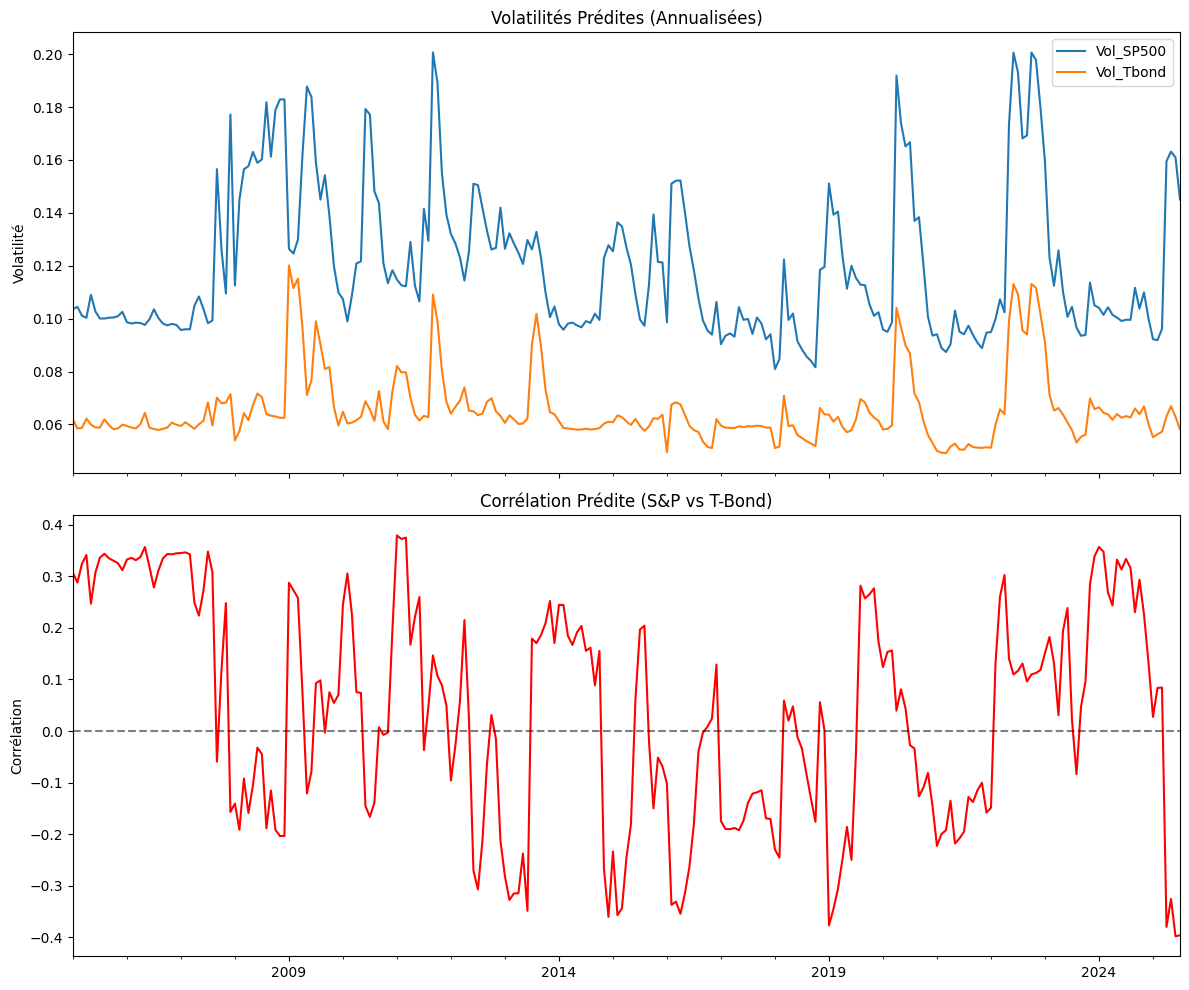

STATISTIQUES DES MODÈLES RETENUS :
method
random        0.52381
Warm-Start    0.47619
Name: proportion, dtype: float64


In [13]:
# 1. Configuration du backtest
n_regimes_max = 4 # choisira entre 4 et 2 régimes

# 2. Choix du type de detecteur
market_detector = HMMMarketRegimeDetector(
    n_regimes=n_regimes_max,
    n_dim=len(ASSET_VARS),
    random_state=SEED, transition_kwargs={"kappa":30}
)

# 3. Init du backtester
backtester = GenericHMMBacktester(
    detector=market_detector,
    data_df=df,               # DataFrame brut
    obs_vars=ASSET_VARS,      # observations du HMM
    asset_vars=ASSET_VARS,    # les actifs dont on veut prédire la matrice de cov
    input_vars=None,          # Pas de macro ici
    refit_freq=12,             # On re-fitte le modèle tous les ans (12 mois)
    scaling_factor=100.0,     # scaling de 100 des log returns pour stabilité numérique
    sig_threshold=0.5,         # pourcentage de tests de séparabilité pour accepter un modèle
    min_duration=3,           # durée minimale de chaque régime de chaque HMM
    min_freq=0.02,            # fréquence min
    sig_max_cond_number=1e7, # max cond number de la hessienne
    min_confidence=0.7,     # entropie min
)

# 4. Lancement du backtest
# On commence en 2005 pour avoir assez d'historique d'entraînement (depuis 1970)

print(f"Lancement du backtest de {len(df.index[df.index >= '2005-01-01'])} mois...")
backtester.run(start_date="2005-01-01", end_date="2025-12-01") # lancement du backtest

# 5. Récupération de matrices de cov prédites et affichages
df_risk = backtester.get_risk_df()

# Visualisation simple
fig, ax = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

df_risk[['Vol_SP500', 'Vol_Tbond']].plot(ax=ax[0], title="Volatilités Prédites (Annualisées)")
ax[0].set_ylabel("Volatilité")

df_risk['Correlation'].plot(ax=ax[1], title="Corrélation Prédite (S&P vs T-Bond)", color='red')
ax[1].axhline(0, color='black', linestyle='--', alpha=0.5)
ax[1].set_ylabel("Corrélation")

plt.tight_layout()
plt.show()

# Vérification des logs de stabilité
print("STATISTIQUES DES MODÈLES RETENUS :")
history = pd.DataFrame(backtester.history_logs)
print(history['method'].value_counts(normalize=True)) # Pour voir le % de Warm-Start

# Zoom sur une période particulière

## 2008

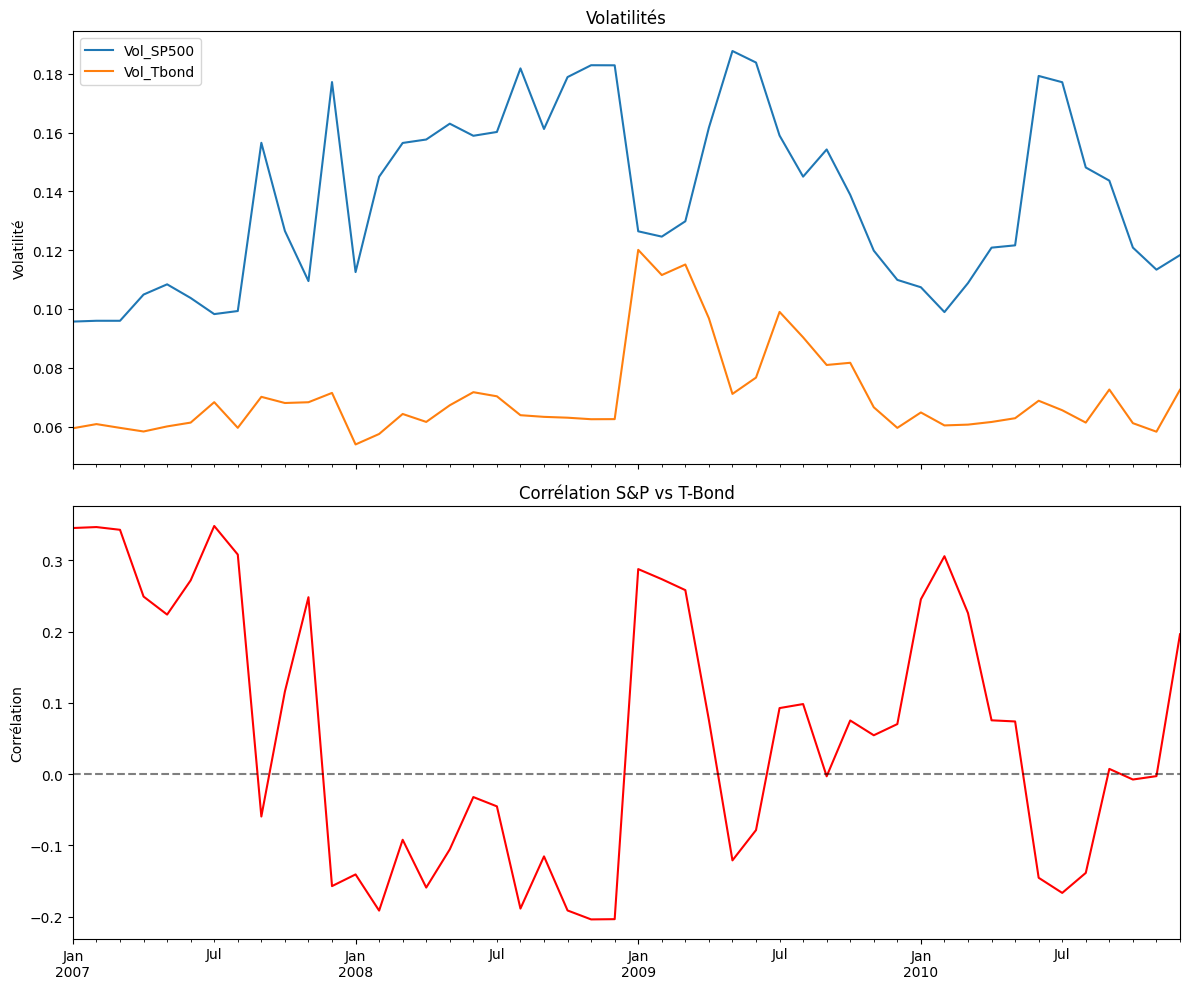

In [14]:
# ZOOM SUR LA CRISE DES SUBPRIMES
df_zoom = df_risk['2007-01-01':'2010-12-31']

fig, ax = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

df_zoom[['Vol_SP500', 'Vol_Tbond']].plot(ax=ax[0], title="Volatilités")
ax[0].set_ylabel("Volatilité")

df_zoom['Correlation'].plot(ax=ax[1], title="Corrélation S&P vs T-Bond", color='red')
ax[1].axhline(0, color='black', linestyle='--', alpha=0.5)
ax[1].set_ylabel("Corrélation")

plt.tight_layout()
plt.show()

On peut donc voir que la volatilité du S&P semble monter bien avant septembre 2008 (de manière certaine en début 2008, avec des signaux en septembre en voyant les returns d'août). Cependant, le modèle semble prédire une baisse du risque en janvier 2009 mais remonte directement après, ce qui semble être un mauvais signal. Ainsi, un lissage du signal semble être nécessaire pour ce modèle (ou aussi un refit plus fréquent).

Concernant le signe de la corrélation, elle est bien négative car pendant cette crise les t-bond10y ont servi de refuge aux actions (Flight-to-quality)

## 2020

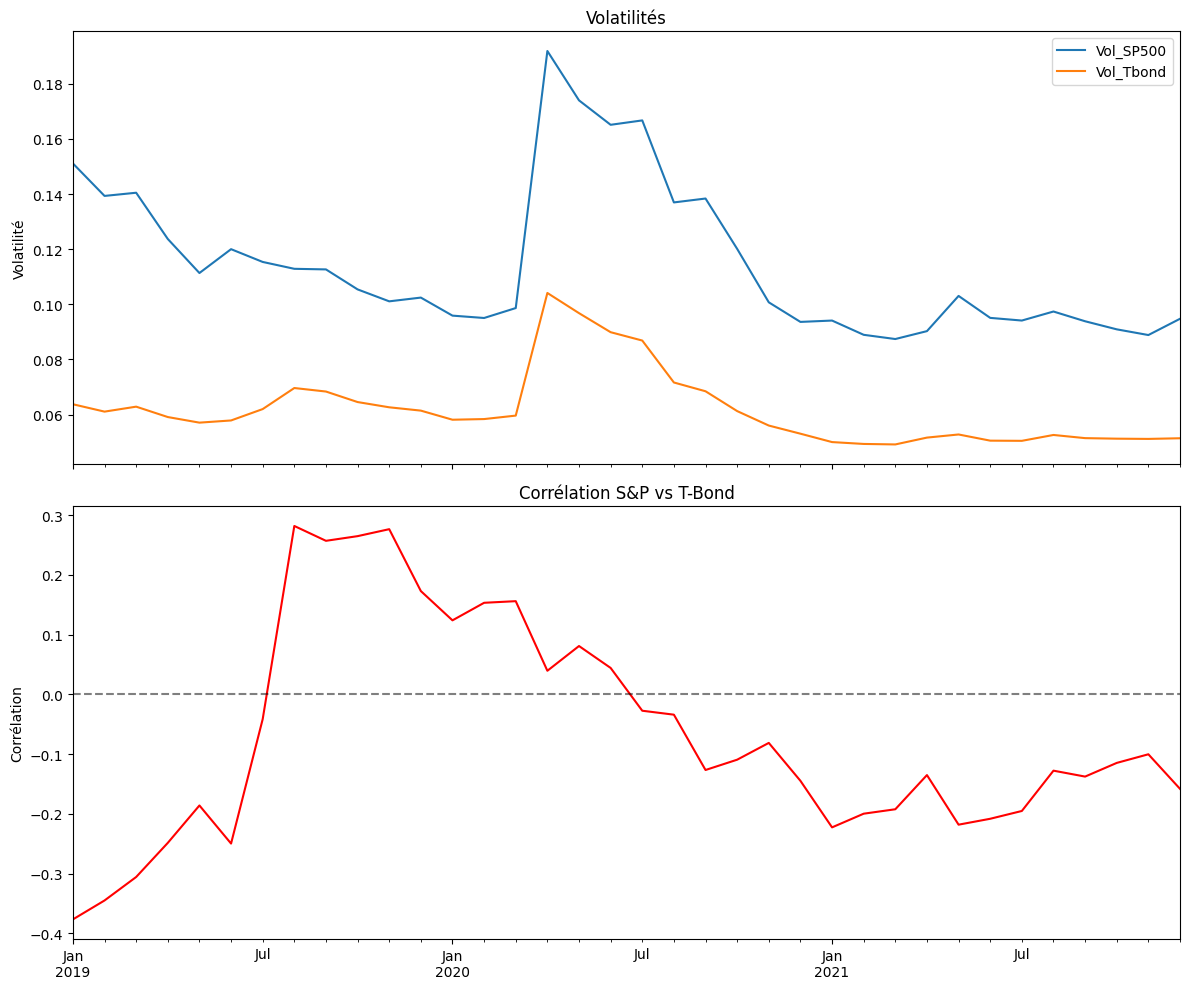

In [15]:
# ZOOM SUR LA CRISE DES SUBPRIMES
df_zoom = df_risk['2019-01-01':'2021-12-31']

fig, ax = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

df_zoom[['Vol_SP500', 'Vol_Tbond']].plot(ax=ax[0], title="Volatilités")
ax[0].set_ylabel("Volatilité")

df_zoom['Correlation'].plot(ax=ax[1], title="Corrélation S&P vs T-Bond", color='red')
ax[1].axhline(0, color='black', linestyle='--', alpha=0.5)
ax[1].set_ylabel("Corrélation")

plt.tight_layout()
plt.show()

Ici, on voit clairement que le modèle ne prédit pas mars 2020 car il ne monte que le mois prochain (en voyant les returns de mars). Cela semble tout de même prévisible car le COVID était un choc exogène. Peut-être que la macro aurait pu anticiper avec le IOHMM?

Concernant le signe de la corrélation, elle est bien négative car pendant cette crise les t-bond10y ont servi de refuge aux actions.

## 2022

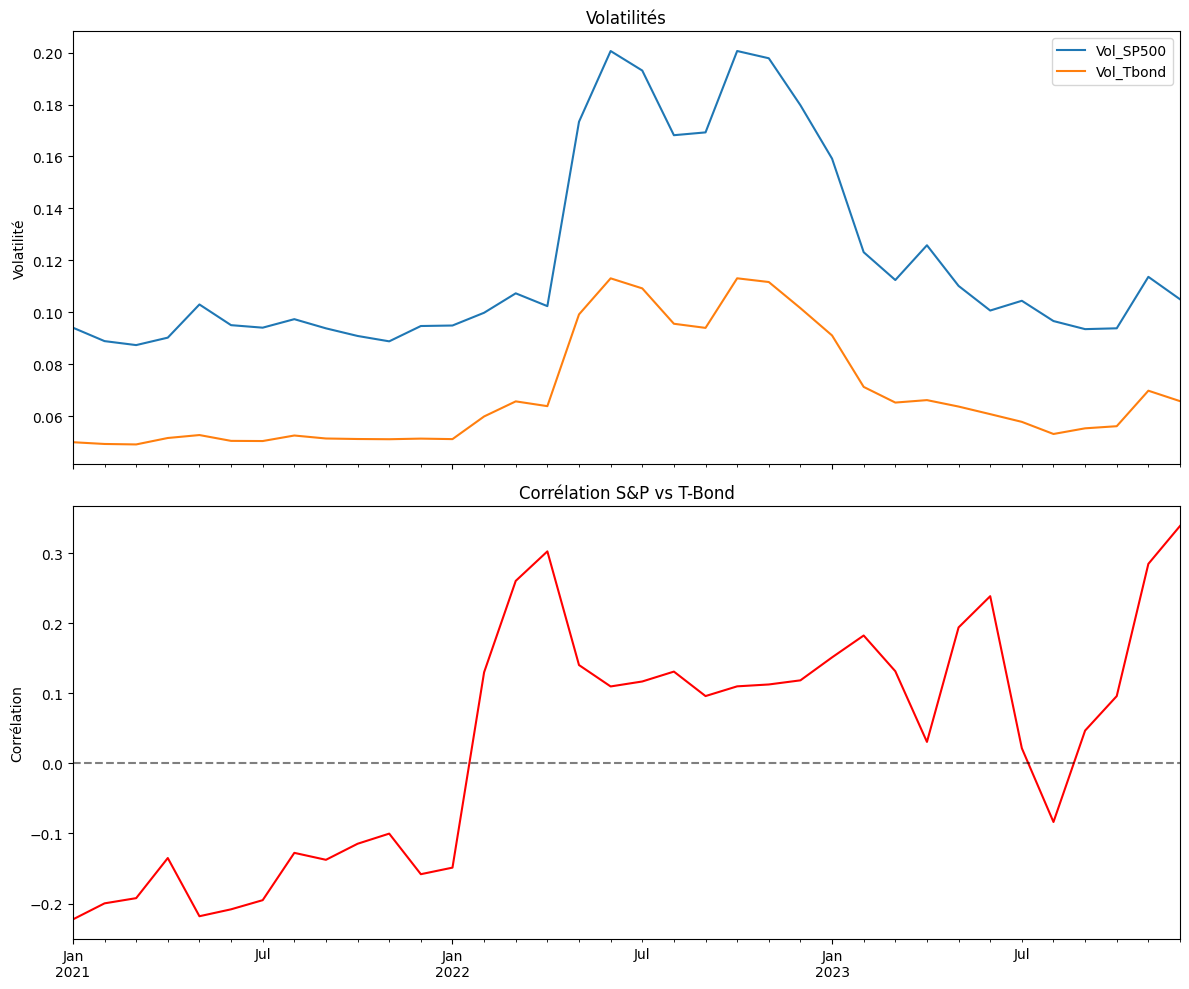

In [17]:
# ZOOM SUR LA CRISE DES SUBPRIMES
df_zoom = df_risk['2021-01-01':'2023-12-31']

fig, ax = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

df_zoom[['Vol_SP500', 'Vol_Tbond']].plot(ax=ax[0], title="Volatilités")
ax[0].set_ylabel("Volatilité")

df_zoom['Correlation'].plot(ax=ax[1], title="Corrélation S&P vs T-Bond", color='red')
ax[1].axhline(0, color='black', linestyle='--', alpha=0.5)
ax[1].set_ylabel("Corrélation")

plt.tight_layout()
plt.show()

Ici, on semble voir un vrai signal prédictif de la part du modèle sur janvier 2022 : la volatilité du S&P monte bien et la corrélation devient positive (crise de staflation).